# Clasificación de Sentimientos de Reseñas IMDb con LSTM optimizada

Este notebook implementa un pipeline más liviano y rápido para Google Colab. Conserva los elementos requeridos del proyecto: descarga desde KaggleHub, limpieza textual, tokenización, embeddings entrenables, arquitectura recurrente LSTM/GRU, entrenamiento por 10 épocas, evaluación con accuracy, precision, recall y F1-score, visualización del modelo con `plot_model`, tabla de embeddings y reducción UMAP 3D coloreada según la clasificación positiva o negativa de reseñas.

Diego Fernando Becerra Zambrano

Andrea Johanna Tellez Acosta

Juan David Rubiano Granada

Profesor: Luis Felipe Giraldo Trujillo

Técnicas de Deep Learning

## 1. Instalación de librerías

Se instalan las dependencias necesarias para descargar el dataset, entrenar el modelo, visualizar la arquitectura y construir la proyección 3D de embeddings.

In [2]:
# Instalación de librerías necesarias para Google Colab
!pip install kagglehub umap-learn plotly pydot graphviz -q
!apt-get install graphviz -y > /dev/null

## 2. Importación de librerías

Se importan herramientas para procesamiento de datos, modelado neuronal, evaluación y visualización.

In [3]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import umap
import plotly.express as px

from IPython.display import Image, display

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 3. Reproducibilidad y configuración de ejecución

Se fija una semilla para estabilizar el experimento. También se intenta activar crecimiento dinámico de memoria en GPU, lo cual evita algunos errores comunes en Colab.

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuración ligera para GPU en Colab, si está disponible
try:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada: {gpus}")
    else:
        print("No se detectó GPU. El notebook funcionará, pero puede tardar más.")
except Exception as e:
    print("No fue posible configurar la GPU:", e)

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Descarga del dataset desde KaggleHub

El dataset se descarga directamente desde KaggleHub. Esta forma facilita la reproducción del notebook en Google Colab.

In [8]:
path = kagglehub.dataset_download("yasserh/imdb-movie-ratings-sentiment-analysis")

print("Ruta del dataset:", path)
print("Archivos encontrados:")
print(os.listdir(path))

Using Colab cache for faster access to the 'imdb-movie-ratings-sentiment-analysis' dataset.
Ruta del dataset: /kaggle/input/imdb-movie-ratings-sentiment-analysis
Archivos encontrados:
['movie.csv']


## 5. Carga automática del archivo CSV

Se localiza el archivo `.csv` descargado y se carga como DataFrame.

In [9]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Archivos CSV detectados:")
for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("No se encontró ningún archivo CSV en la carpeta descargada.")

df = pd.read_csv(csv_files[0])

print("Dimensiones del dataset:", df.shape)
df.head()

Archivos CSV detectados:
/kaggle/input/imdb-movie-ratings-sentiment-analysis/movie.csv
Dimensiones del dataset: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## 6. Revisión inicial del dataset

Se inspeccionan columnas, valores faltantes y distribución de clases.

In [10]:
print("Columnas disponibles:")
print(df.columns)

print("\nInformación general:")
print(df.info())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDistribución de etiquetas:")
print(df["label"].value_counts())

Columnas disponibles:
Index(['text', 'label'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None

Valores faltantes:
text     0
label    0
dtype: int64

Distribución de etiquetas:
label
0    20019
1    19981
Name: count, dtype: int64


## 7. Limpieza básica del dataset

Se validan las columnas requeridas, se eliminan duplicados y se conservan únicamente las etiquetas binarias esperadas.

In [11]:
df = df.copy()

required_columns = ["text", "label"]
for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"No se encontró la columna requerida: {column}")

df = df[["text", "label"]]
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

df = df.drop_duplicates(subset=["text"])
df = df.dropna(subset=["text", "label"])
df = df[df["label"].isin([0, 1])]

print("Dimensiones después de limpieza:", df.shape)
print(df["label"].value_counts())

Dimensiones después de limpieza: (39723, 2)
label
1    19908
0    19815
Name: count, dtype: int64


## 8. Limpieza textual

La limpieza textual elimina etiquetas HTML, enlaces, caracteres extraños y espacios repetidos. Se conserva una versión simplificada de las reseñas, suficiente para el modelo recurrente.

In [12]:
def clean_text(text):
    """
    Limpia una reseña antes de entregarla al vectorizador.
    """
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,I grew up (b. 1965) watching and loving the Th...,i grew up b watching and loving the thunderbir...,0
1,"When I put this movie in my DVD player, and sa...",when i put this movie in my dvd player and sat...,0
2,Why do people who do not know what a particula...,why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,even though i have great interest in biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,im a die hard dads army fan and nothing will e...,1


## 9. División en entrenamiento, validación y prueba

Se usa una partición 70 %, 15 % y 15 %. La estratificación mantiene el balance entre reseñas positivas y negativas.

In [13]:
X = df["clean_text"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (27806,) (27806,)
Validación: (5958,) (5958,)
Prueba: (5959,) (5959,)


## 10. Parámetros optimizados para ejecución rápida

Estos valores buscan un equilibrio entre velocidad y desempeño. El modelo entrena 10 épocas, aunque `EarlyStopping` puede detenerlo antes si empieza a sobreajustarse.

In [14]:
MAX_TOKENS = 15000
SEQUENCE_LENGTH = 160
EMBEDDING_DIM = 96
BATCH_SIZE = 128
EPOCHS = 10

print("MAX_TOKENS:", MAX_TOKENS)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("EMBEDDING_DIM:", EMBEDDING_DIM)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)

MAX_TOKENS: 15000
SEQUENCE_LENGTH: 160
EMBEDDING_DIM: 96
BATCH_SIZE: 128
EPOCHS: 10


## 11. Vectorización del texto

`TextVectorization` aprende el vocabulario con los datos de entrenamiento y convierte cada reseña en una secuencia de índices numéricos.

In [15]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    name="vectorizacion_texto"
)

vectorizer.adapt(X_train)

vocabulary = vectorizer.get_vocabulary()

print("Tamaño del vocabulario:", len(vocabulary))
print("Primeras palabras del vocabulario:")
print(vocabulary[:20])

Tamaño del vocabulario: 15000
Primeras palabras del vocabulario:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('movie'), np.str_('but'), np.str_('film')]


## 12. Datasets eficientes con `tf.data`

Se prepara la entrada del modelo con `batch`, `shuffle`, `cache` y `prefetch`. Esta modificación ayuda a acelerar el entrenamiento en Colab.

In [16]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

for text_batch, label_batch in train_ds.take(1):
    print("Ejemplo de texto:", text_batch[0].numpy()[:200])
    print("Etiqueta:", label_batch[0].numpy())

Ejemplo de texto: b'i went to see this movie expecting a nice relaxing time in the theater with my younger sister instead i had to really control myself in order to convince her that i was not scared in many ways still a'
Etiqueta: 1


## 13. Ejemplo de vectorización

Esta celda muestra cómo una reseña textual pasa a una secuencia de números.

In [17]:
sample_text = X_train[0]
sample_vector = vectorizer(tf.constant([sample_text]))

print("Texto original limpio:")
print(sample_text[:500])

print("\nSecuencia numérica:")
print(sample_vector.numpy()[0][:80])

Texto original limpio:
well i like patricia kaas she is a beautiful lady and an extremely gifted and versatile singer her acting in this film is more than competent and from my point of view about the only redeeming feauture of this film she very gently captures the essence of the lonely singer with a very serious helath problem however what i tremendously dislike about the film is the shameless product placement for a well known french chain of hotels the other thing is that the story seems to meander for way to long

Secuencia numérica:
[   69    10    38  4943     1    59     7     4   306   756     3    33
   569  4718     3  8807  1715    41   111     8    11    19     7    50
    72  3187     3    37    57   221     5   643    43     2    62  1663
     1     5    11    19    59    52  8319  2399     2  3171     5     2
  2842  1715    16     4    52   601     1   462   192    48    10  6400
  3218    43     2    19     7     2  7273  2171  8408    15     4    69
   539   713  330

## 14. Construcción de dos modelos recurrentes: LSTM vs GRU

Se crean dos arquitecturas idénticas, la única diferencia es la capa recurrente: una con LSTM y otra con GRU. Esto permite comparar directamente el desempeño, overfitting y velocidad de ambas celdas recurrentes.

In [18]:
def build_model(model_type="LSTM"):
    """
    Construye un modelo recurrente bidireccional.

    Args:
        model_type: "LSTM" o "GRU"

    Returns:
        Modelo compilado
    """
    input_text = layers.Input(shape=(1,), dtype=tf.string, name="entrada_texto")

    x = vectorizer(input_text)

    x = layers.Embedding(
        input_dim=len(vocabulary),
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="capa_embedding"
    )(x)

    # Seleccionar la capa recurrente según el tipo
    if model_type == "LSTM":
        recurrent_layer_1 = layers.Bidirectional(
            layers.LSTM(
                units=64,
                return_sequences=True,
                dropout=0.30,
                recurrent_dropout=0.20
            ),
            name=f"bilstm_1"
        )
        recurrent_layer_2 = layers.Bidirectional(
            layers.LSTM(
                units=32,
                return_sequences=False,
                dropout=0.30,
                recurrent_dropout=0.20
            ),
            name=f"bilstm_2"
        )
    else:  # GRU
        recurrent_layer_1 = layers.Bidirectional(
            layers.GRU(
                units=64,
                return_sequences=True,
                dropout=0.30,
                recurrent_dropout=0.20
            ),
            name=f"bigru_1"
        )
        recurrent_layer_2 = layers.Bidirectional(
            layers.GRU(
                units=32,
                return_sequences=False,
                dropout=0.30,
                recurrent_dropout=0.20
            ),
            name=f"bigru_2"
        )

    x = recurrent_layer_1(x)
    x = recurrent_layer_2(x)

    x = layers.Dense(64, activation="relu", name="capa_densa_1")(x)
    x = layers.Dropout(0.40, name="dropout_1")(x)

    x = layers.Dense(32, activation="relu", name="capa_densa_2")(x)
    x = layers.Dropout(0.30, name="dropout_2")(x)

    output = layers.Dense(1, activation="sigmoid", name="salida_sentimiento")(x)

    model = Model(inputs=input_text, outputs=output, name=f"IMDb_BiRecurrent_{model_type}_Sentiment_Classifier")

    return model

# Construir ambos modelos
model_lstm = build_model("LSTM")
model_gru = build_model("GRU")

print("=" * 70)
print("MODELO LSTM")
print("=" * 70)
model_lstm.summary()

print("\n" + "=" * 70)
print("MODELO GRU")
print("=" * 70)
model_gru.summary()

MODELO LSTM


Model: "IMDb_BiRecurrent_LSTM_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_texto       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectorizacion_texto │ (None, 160)       │          0 │ entrada_texto[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_embedding      │ (None, 160, 96)   │  1,440,000 │ vectorizacion_te… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 160)       │          0 │ vectorizacion_te… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 160, 128)  │     82,432 │ capa_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 64)        │     41,216 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_1        │ (None, 64)        │      4,160 │ bilstm_2[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ capa_densa_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_2        │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ capa_densa_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_sentimiento  │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,569,921 (5.99 MB)

 Trainable params: 1,569,921 (5.99 MB)

...

Model: "IMDb_BiRecurrent_GRU_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_texto       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectorizacion_texto │ (None, 160)       │          0 │ entrada_texto[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_embedding      │ (None, 160, 96)   │  1,440,000 │ vectorizacion_te… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 160)       │          0 │ vectorizacion_te… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_1             │ (None, 160, 128)  │     62,208 │ capa_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_2             │ (None, 64)        │     31,104 │ bigru_1[0][0],    │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_1        │ (None, 64)        │      4,160 │ bigru_2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ capa_densa_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capa_densa_2        │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ capa_densa_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_sentimiento  │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,539,585 (5.87 MB)

 Trainable params: 1,539,585 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

## 15. Compilación de ambos modelos

Se compilan ambos modelos con la misma configuración: optimizador Adam, pérdida binary_crossentropy y métricas de accuracy, precision y recall.

In [19]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

for model, model_name in [(model_lstm, "LSTM"), (model_gru, "GRU")]:
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    print(f"Modelo {model_name} compilado correctamente.")

Modelo LSTM compilado correctamente.
Modelo GRU compilado correctamente.


## 16. Visualización gráfica de ambos modelos

Se visualizan las arquitecturas de los modelos LSTM y GRU para observar el flujo de datos y las capas.

Visualizando modelo LSTM...


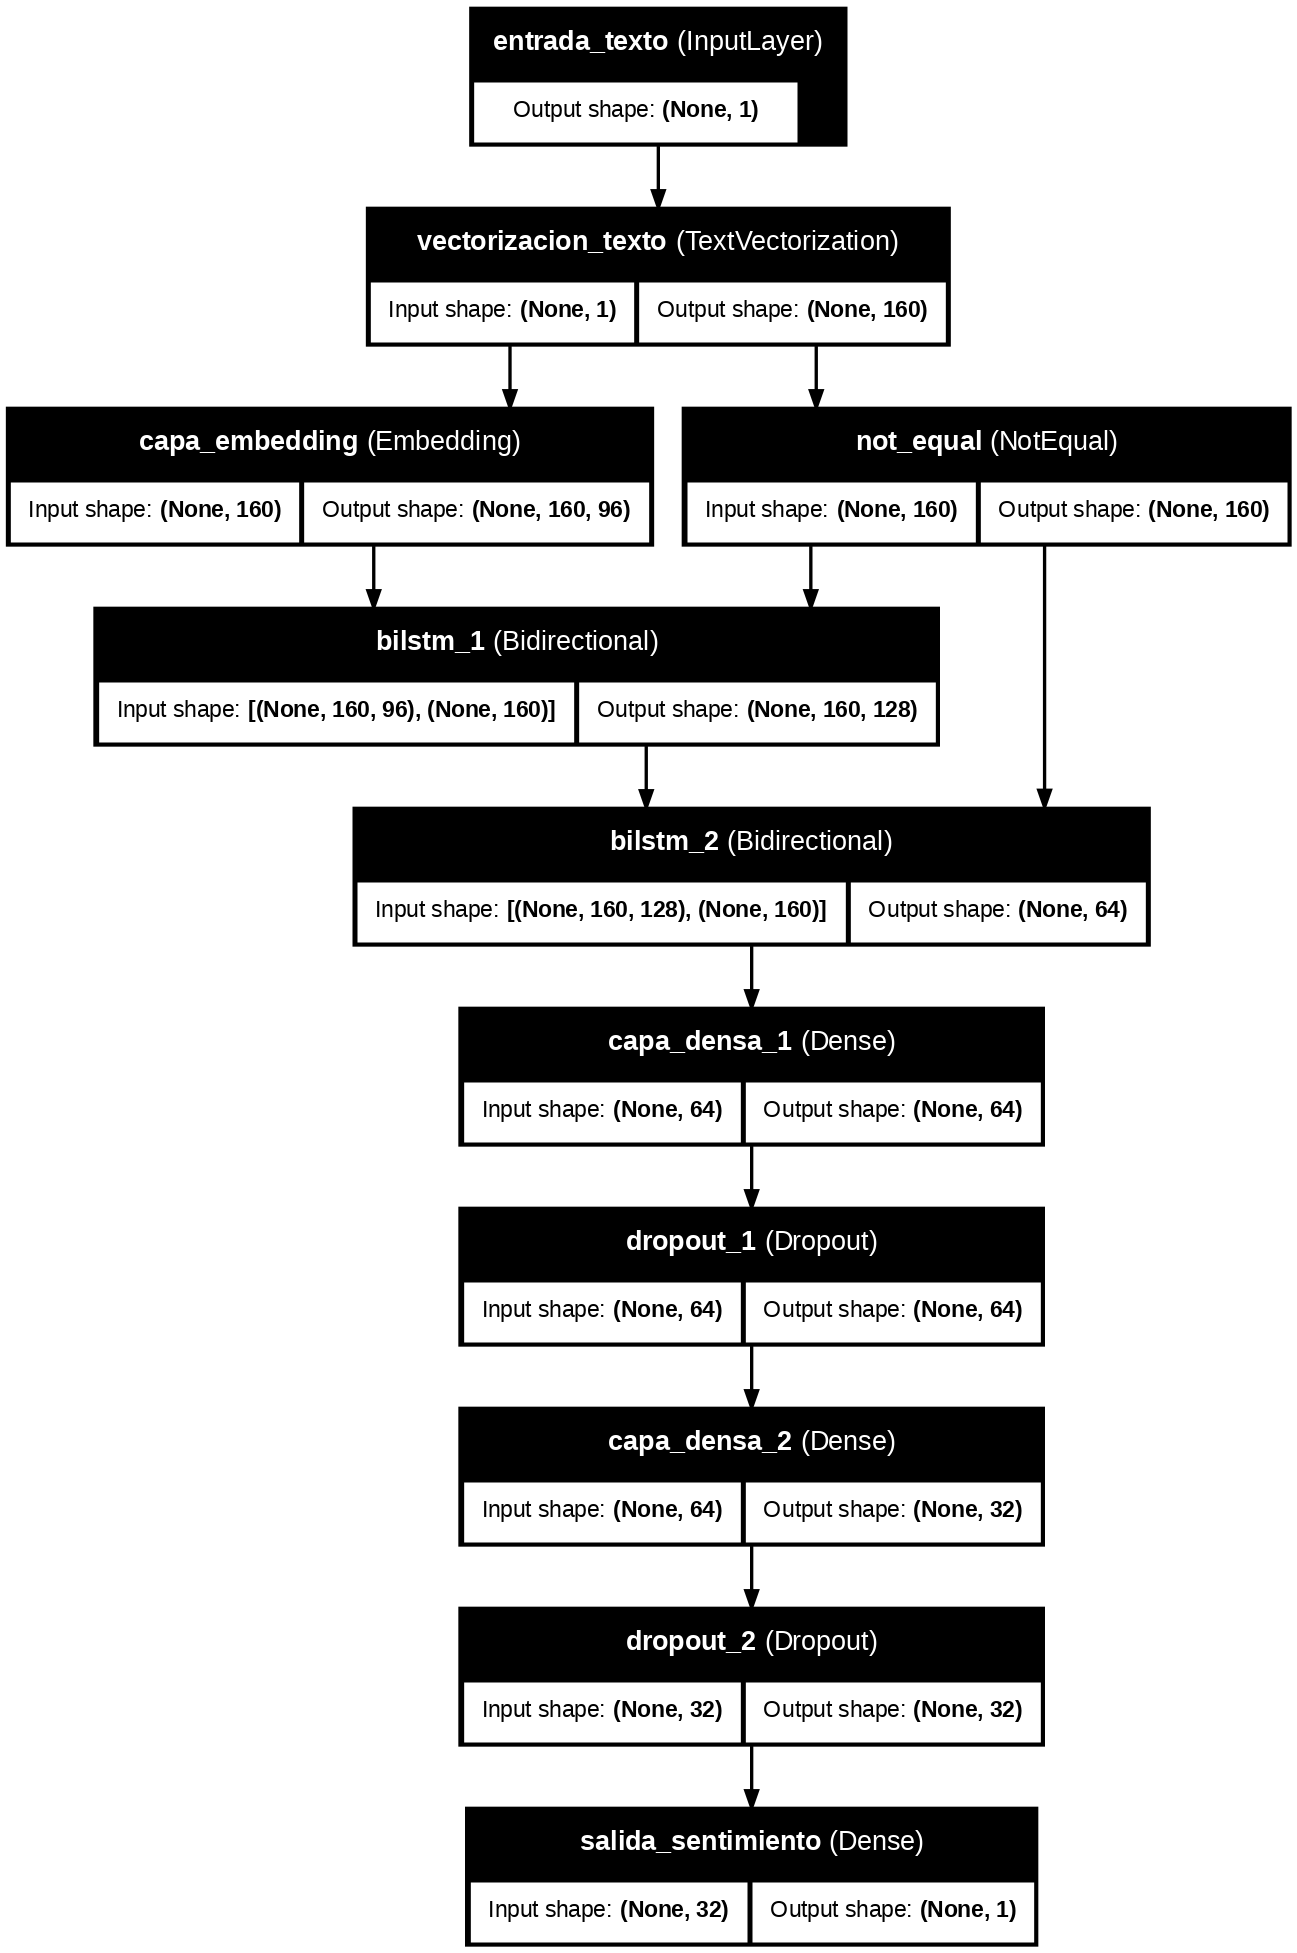


Visualizando modelo GRU...


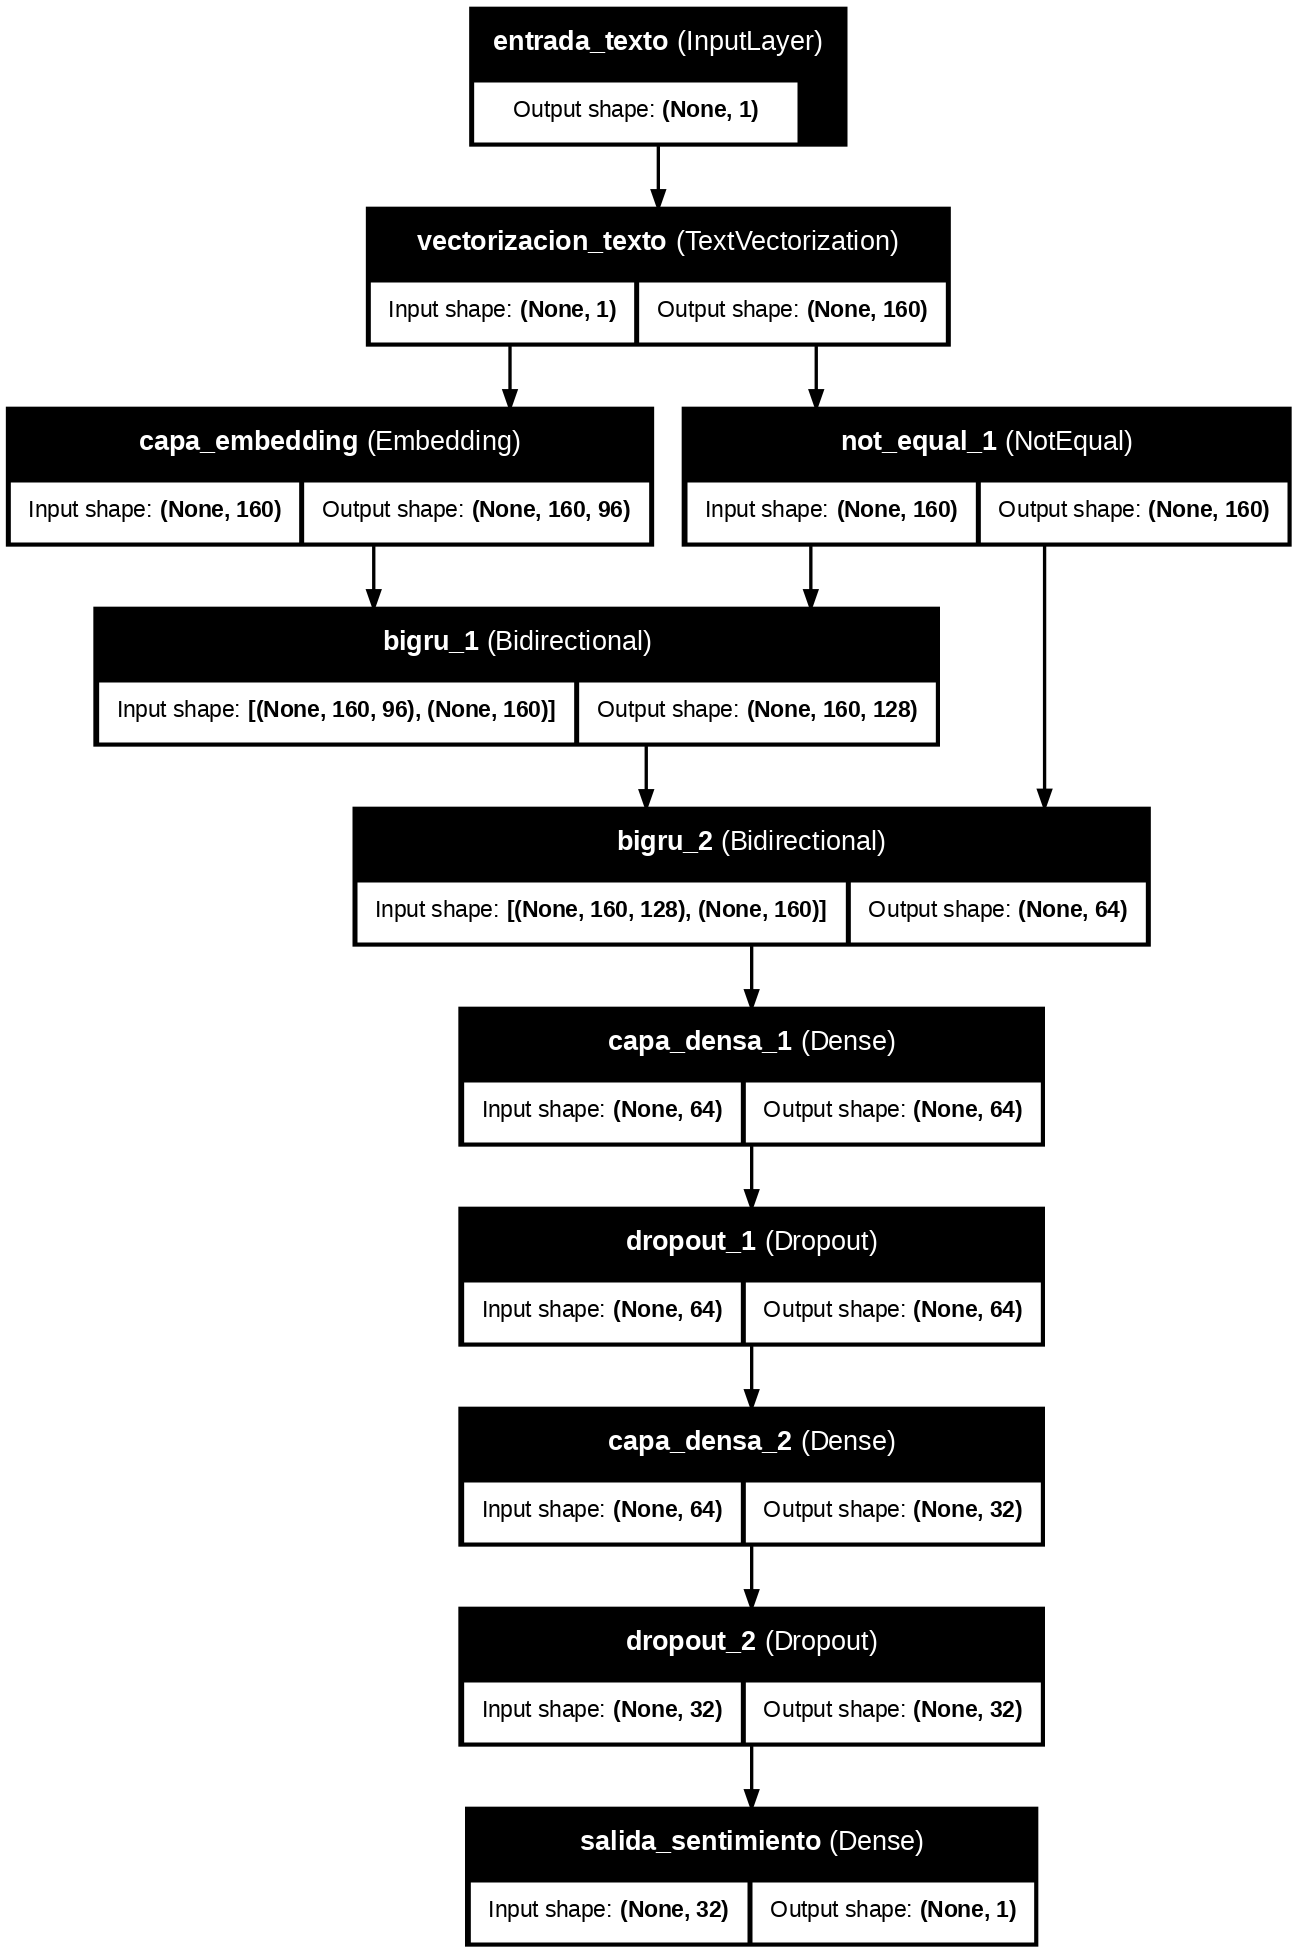

In [20]:
print("Visualizando modelo LSTM...")
plot_model(
    model_lstm,
    to_file="modelo_lstm_imdb.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120
)
display(Image("modelo_lstm_imdb.png"))

print("\nVisualizando modelo GRU...")
plot_model(
    model_gru,
    to_file="modelo_gru_imdb.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120
)
display(Image("modelo_gru_imdb.png"))

## 17. Entrenamiento de ambos modelos con medición de tiempo

Se entrenan los modelos LSTM y GRU con 10 épocas cada uno, midiendo el tiempo total de entrenamiento. Se usa EarlyStopping para detener si la validación no mejora.

In [ ]:
import time

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=1,
    mode="max",
    min_lr=1e-5
)

# Diccionario para almacenar los resultados de entrenamiento
training_results = {}

# Entrenar LSTM
print("=" * 70)
print("ENTRENAMIENTO - MODELO LSTM")
print("=" * 70)
start_time_lstm = time.time()
history_lstm = model_lstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
total_time_lstm = time.time() - start_time_lstm

# Entrenar GRU
print("\n" + "=" * 70)
print("ENTRENAMIENTO - MODELO GRU")
print("=" * 70)
start_time_gru = time.time()
history_gru = model_gru.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
total_time_gru = time.time() - start_time_gru

# Almacenar resultados
training_results["LSTM"] = {
    "history": history_lstm,
    "total_time": total_time_lstm,
    "num_epochs": len(history_lstm.history["loss"])
}

training_results["GRU"] = {
    "history": history_gru,
    "total_time": total_time_gru,
    "num_epochs": len(history_gru.history["loss"])
}

print("\n" + "=" * 70)
print("RESUMEN DE TIEMPOS")
print("=" * 70)
print(f"Tiempo total LSTM: {total_time_lstm:.2f} segundos ({total_time_lstm/60:.2f} minutos)")
print(f"Tiempo total GRU: {total_time_gru:.2f} segundos ({total_time_gru/60:.2f} minutos)")
print(f"Épocas LSTM: {training_results['LSTM']['num_epochs']}")
print(f"Épocas GRU: {training_results['GRU']['num_epochs']}")
print(f"Tiempo promedio por época LSTM: {total_time_lstm/training_results['LSTM']['num_epochs']:.2f} segundos")
print(f"Tiempo promedio por época GRU: {total_time_gru/training_results['GRU']['num_epochs']:.2f} segundos")

ENTRENAMIENTO - MODELO LSTM
Epoch 1/10
 10/218 ━━━━━━━━━━━━━━━━━━━━ 8:53 3s/step - accuracy: 0.5119 - loss: 0.6933 - precision: 0.4836 - recall: 0.1243

## 18. Comparación de curvas de entrenamiento: Performance y Overfitting

Se comparan las curvas de loss y accuracy de ambos modelos para evaluar la performance y el grado de overfitting (brecha train vs validation).

In [ ]:
# Preparar datos para comparación
history_lstm_df = pd.DataFrame(history_lstm.history)
history_gru_df = pd.DataFrame(history_gru.history)

# Gráfico 1: Comparación de Pérdida en Entrenamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss en entrenamiento
axes[0, 0].plot(history_lstm_df["loss"], label="LSTM", marker="o", linewidth=2)
axes[0, 0].plot(history_gru_df["loss"], label="GRU", marker="s", linewidth=2)
axes[0, 0].set_title("Pérdida en Entrenamiento", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("Pérdida")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss en validación
axes[0, 1].plot(history_lstm_df["val_loss"], label="LSTM", marker="o", linewidth=2)
axes[0, 1].plot(history_gru_df["val_loss"], label="GRU", marker="s", linewidth=2)
axes[0, 1].set_title("Pérdida en Validación", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Pérdida")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy en entrenamiento
axes[1, 0].plot(history_lstm_df["accuracy"], label="LSTM", marker="o", linewidth=2)
axes[1, 0].plot(history_gru_df["accuracy"], label="GRU", marker="s", linewidth=2)
axes[1, 0].set_title("Exactitud en Entrenamiento", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylabel("Exactitud")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy en validación
axes[1, 1].plot(history_lstm_df["val_accuracy"], label="LSTM", marker="o", linewidth=2)
axes[1, 1].plot(history_gru_df["val_accuracy"], label="GRU", marker="s", linewidth=2)
axes[1, 1].set_title("Exactitud en Validación", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("Exactitud")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de Overfitting: Brecha entre entrenamiento y validación
print("\n" + "=" * 70)
print("ANÁLISIS DE OVERFITTING (Brecha Train vs Validation)")
print("=" * 70)

lstm_accuracy_gap = history_lstm_df["accuracy"].values - history_lstm_df["val_accuracy"].values
gru_accuracy_gap = history_gru_df["accuracy"].values - history_gru_df["val_accuracy"].values

print(f"\nGRUPO LSTM:")
print(f"  Brecha máxima de accuracy: {lstm_accuracy_gap.max():.4f}")
print(f"  Brecha promedio de accuracy: {lstm_accuracy_gap.mean():.4f}")
print(f"  Brecha final (última época) de accuracy: {lstm_accuracy_gap[-1]:.4f}")

print(f"\nGRUPO GRU:")
print(f"  Brecha máxima de accuracy: {gru_accuracy_gap.max():.4f}")
print(f"  Brecha promedio de accuracy: {gru_accuracy_gap.mean():.4f}")
print(f"  Brecha final (última época) de accuracy: {gru_accuracy_gap[-1]:.4f}")

## 19. Comparación de rendimiento en el conjunto de prueba

Se evalúan ambos modelos con datos no vistos y se comparan las métricas finales: accuracy, precision, recall y F1-score.

In [ ]:
# Evaluar ambos modelos en el conjunto de prueba
test_results_lstm = model_lstm.evaluate(test_ds, return_dict=True, verbose=0)
test_results_gru = model_gru.evaluate(test_ds, return_dict=True, verbose=0)

# Hacer predicciones
y_prob_lstm = model_lstm.predict(tf.constant(X_test), batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

y_prob_gru = model_gru.predict(tf.constant(X_test), batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred_gru = (y_prob_gru >= 0.5).astype(int)

# Calcular métricas
metrics_lstm = {
    "Accuracy": accuracy_score(y_test, y_pred_lstm),
    "Precision": precision_score(y_test, y_pred_lstm),
    "Recall": recall_score(y_test, y_pred_lstm),
    "F1-score": f1_score(y_test, y_pred_lstm)
}

metrics_gru = {
    "Accuracy": accuracy_score(y_test, y_pred_gru),
    "Precision": precision_score(y_test, y_pred_gru),
    "Recall": recall_score(y_test, y_pred_gru),
    "F1-score": f1_score(y_test, y_pred_gru)
}

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    "LSTM": metrics_lstm,
    "GRU": metrics_gru
})

print("\n" + "=" * 70)
print("COMPARACIÓN DE RENDIMIENTO EN PRUEBA")
print("=" * 70)
print(comparison_df)
print("\n")

# Tabla de visualización
comparison_display = comparison_df.copy()
comparison_display.loc["Diferencia (LSTM - GRU)"] = comparison_display.loc["Accuracy"] - comparison_display.loc["Accuracy"]
for metric in metrics_lstm.keys():
    lstm_val = metrics_lstm[metric]
    gru_val = metrics_gru[metric]
    diff = lstm_val - gru_val
    print(f"{metric}:")
    print(f"  LSTM: {lstm_val:.4f}")
    print(f"  GRU:  {gru_val:.4f}")
    print(f"  Diferencia: {diff:+.4f}\n")

## 20. Análisis comparativo: Visualización de resultados

Se crea un análisis gráfico de la velocidad y las métricas de rendimiento para facilitar la comparación.

In [ ]:
# Crear visualizaciones comparativas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparación de Métricas en Prueba
metrics_names = list(metrics_lstm.keys())
lstm_values = list(metrics_lstm.values())
gru_values = list(metrics_gru.values())

x_pos = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x_pos - width/2, lstm_values, width, label="LSTM", alpha=0.8)
axes[0, 0].bar(x_pos + width/2, gru_values, width, label="GRU", alpha=0.8)
axes[0, 0].set_ylabel("Valor")
axes[0, 0].set_title("Comparación de Métricas en Prueba", fontsize=12, fontweight="bold")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis="y")
axes[0, 0].set_ylim([0.8, 1.0])

# 2. Tiempo de Entrenamiento
models = ["LSTM", "GRU"]
times = [training_results["LSTM"]["total_time"], training_results["GRU"]["total_time"]]
bars = axes[0, 1].bar(models, times, color=["#1f77b4", "#ff7f0e"], alpha=0.8)
axes[0, 1].set_ylabel("Tiempo (segundos)")
axes[0, 1].set_title("Tiempo Total de Entrenamiento", fontsize=12, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Agregar valores en las barras
for bar, time in zip(bars, times):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f"{time/60:.2f} min",
                    ha="center", va="bottom", fontweight="bold")

# 3. Tiempo Promedio por Época
avg_times_per_epoch = [
    training_results["LSTM"]["total_time"] / training_results["LSTM"]["num_epochs"],
    training_results["GRU"]["total_time"] / training_results["GRU"]["num_epochs"]
]
bars = axes[1, 0].bar(models, avg_times_per_epoch, color=["#1f77b4", "#ff7f0e"], alpha=0.8)
axes[1, 0].set_ylabel("Tiempo (segundos)")
axes[1, 0].set_title("Tiempo Promedio por Época", fontsize=12, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Agregar valores en las barras
for bar, time in zip(bars, avg_times_per_epoch):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f"{time:.2f} s",
                    ha="center", va="bottom", fontweight="bold")

# 4. Resumen de Overfitting (Brecha Final)
final_gap_lstm = lstm_accuracy_gap[-1]
final_gap_gru = gru_accuracy_gap[-1]
gaps = [final_gap_lstm, final_gap_gru]
bars = axes[1, 1].bar(models, gaps, color=["#1f77b4", "#ff7f0e"], alpha=0.8)
axes[1, 1].set_ylabel("Brecha de Accuracy")
axes[1, 1].set_title("Overfitting: Brecha Train-Validation (Última Época)", fontsize=12, fontweight="bold")
axes[1, 1].grid(True, alpha=0.3, axis="y")
axes[1, 1].axhline(y=0, color="k", linestyle="-", linewidth=0.5)

# Agregar valores en las barras
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f"{gap:.4f}",
                    ha="center", va="bottom" if gap >= 0 else "top", fontweight="bold")

plt.tight_layout()
plt.show()

# Tabla resumen final
print("\n" + "=" * 70)
print("TABLA RESUMEN COMPARATIVA")
print("=" * 70)

summary_data = {
    "Métrica": [
        "Accuracy en Prueba",
        "Precision en Prueba",
        "Recall en Prueba",
        "F1-score en Prueba",
        "Tiempo Total (min)",
        "Tiempo por Época (s)",
        "Brecha Overfitting Final",
        "Épocas Entrenadas"
    ],
    "LSTM": [
        f"{metrics_lstm['Accuracy']:.4f}",
        f"{metrics_lstm['Precision']:.4f}",
        f"{metrics_lstm['Recall']:.4f}",
        f"{metrics_lstm['F1-score']:.4f}",
        f"{training_results['LSTM']['total_time']/60:.2f}",
        f"{training_results['LSTM']['total_time']/training_results['LSTM']['num_epochs']:.2f}",
        f"{final_gap_lstm:.4f}",
        str(training_results['LSTM']['num_epochs'])
    ],
    "GRU": [
        f"{metrics_gru['Accuracy']:.4f}",
        f"{metrics_gru['Precision']:.4f}",
        f"{metrics_gru['Recall']:.4f}",
        f"{metrics_gru['F1-score']:.4f}",
        f"{training_results['GRU']['total_time']/60:.2f}",
        f"{training_results['GRU']['total_time']/training_results['GRU']['num_epochs']:.2f}",
        f"{final_gap_gru:.4f}",
        str(training_results['GRU']['num_epochs'])
    ]
}

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))

## 21. Matrices de confusión de ambos modelos

Se visualizan las matrices de confusión para ambos modelos a fin de ver el desglose de predicciones correctas e incorrectas.

In [ ]:
# Crear matrices de confusión para ambos modelos
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_gru = confusion_matrix(y_test, y_pred_gru)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión LSTM
disp_lstm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Negativa", "Positiva"]
)
disp_lstm.plot(ax=axes[0], values_format="d", cmap="Blues")
axes[0].set_title("Matriz de Confusión - LSTM", fontsize=12, fontweight="bold")

# Matriz de confusión GRU
disp_gru = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Negativa", "Positiva"]
)
disp_gru.plot(ax=axes[1], values_format="d", cmap="Oranges")
axes[1].set_title("Matriz de Confusión - GRU", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 22. Reporte detallado de clasificación

Se muestran los reportes detallados de precisión, recall y F1-score para ambos modelos.

In [ ]:
print("\n" + "=" * 70)
print("REPORTE DETALLADO - MODELO LSTM")
print("=" * 70)
print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=["Negativa", "Positiva"],
    digits=4
))

print("\n" + "=" * 70)
print("REPORTE DETALLADO - MODELO GRU")
print("=" * 70)
print(classification_report(
    y_test,
    y_pred_gru,
    target_names=["Negativa", "Positiva"],
    digits=4
))

## 23. Clasificación de reseñas aleatorias con ambos modelos

Se toman reseñas al azar y se compara la predicción de ambos modelos.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión")
plt.show()

## 22. Clasificación de reseñas aleatorias del dataset

Se toman reseñas al azar y se compara la etiqueta real con la predicción del modelo.

In [ ]:
def predict_sentiment_both(review, model_lstm, model_gru):
    """
    Recibe una reseña y devuelve predicciones de ambos modelos.
    """
    review_clean = clean_text(review)
    review_tensor = tf.constant([review_clean])

    prob_lstm = model_lstm.predict(review_tensor, verbose=0)[0][0]
    prob_gru = model_gru.predict(review_tensor, verbose=0)[0][0]

    label_lstm = "Positiva" if prob_lstm >= 0.5 else "Negativa"
    label_gru = "Positiva" if prob_gru >= 0.5 else "Negativa"

    return {
        "lstm_prob": float(prob_lstm),
        "lstm_label": label_lstm,
        "gru_prob": float(prob_gru),
        "gru_label": label_gru
    }

sample_df = df.sample(10, random_state=SEED).copy()

results = []
for _, row in sample_df.iterrows():
    result = predict_sentiment_both(row["text"], model_lstm, model_gru)
    results.append({
        "reseña": row["text"][:200] + "...",
        "etiqueta_real": "Positiva" if row["label"] == 1 else "Negativa",
        "LSTM_pred": result["lstm_label"],
        "LSTM_prob": result["lstm_prob"],
        "GRU_pred": result["gru_label"],
        "GRU_prob": result["gru_prob"],
        "acuerdo": "✓" if result["lstm_label"] == result["gru_label"] else "✗"
    })

comparison_predictions_df = pd.DataFrame(results)
print("\nPREDICCIONES COMPARATIVAS (LSTM vs GRU):")
print(comparison_predictions_df.to_string(index=False))

## 24. Extracción de la matriz de embeddings del modelo LSTM

La capa de embeddings del modelo LSTM contiene un vector para cada palabra del vocabulario. Se extrae para análisis posterior.

In [ ]:
# Usar el modelo LSTM para la visualización de embeddings
# (Ambos modelos tienen la misma capa de embedding, la estructura es idéntica)
embedding_layer = model_lstm.get_layer("capa_embedding")
embedding_matrix = embedding_layer.get_weights()[0]

print("Forma de la matriz de embeddings:", embedding_matrix.shape)

## 25. Tabla de embeddings por palabra

Cada fila representa una palabra del vocabulario y cada columna una dimensión del vector aprendido.

In [ ]:
embedding_df = pd.DataFrame(
    embedding_matrix,
    columns=[f"dim_{i}" for i in range(EMBEDDING_DIM)]
)

embedding_df.insert(0, "word", vocabulary)

embedding_df.head(20)

## 26. Embeddings de palabras frecuentes

Se observan algunas palabras frecuentes del vocabulario y sus representaciones vectoriales.

In [ ]:
selected_words = vocabulary[2:52]
selected_embeddings = embedding_df[embedding_df["word"].isin(selected_words)]
selected_embeddings.head(10)

## 27. UMAP 3D coloreado según clasificación positiva o negativa

Se crea una proyección 3D de reseñas donde cada punto es el promedio de embeddings de sus palabras. El color representa la clasificación predicha por el modelo LSTM.

In [ ]:
# Número de reseñas a visualizar. Se mantiene moderado para que UMAP sea rápido.
N_REVIEWS_UMAP = min(1200, len(X_test))

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test), size=N_REVIEWS_UMAP, replace=False)

X_umap_text = X_test[sample_indices]
y_umap_real = y_test[sample_indices]

# Vectorización de reseñas seleccionadas
sequences_umap = vectorizer(tf.constant(X_umap_text)).numpy()

# Promedio de embeddings por reseña, ignorando el padding 0
review_vectors = []
for sequence in sequences_umap:
    token_ids = sequence[sequence != 0]
    if len(token_ids) == 0:
        review_vectors.append(np.zeros(EMBEDDING_DIM))
    else:
        review_vectors.append(embedding_matrix[token_ids].mean(axis=0))

review_vectors = np.array(review_vectors)

# Predicción del modelo LSTM sobre esas reseñas
y_umap_prob = model_lstm.predict(tf.constant(X_umap_text), batch_size=BATCH_SIZE, verbose=0).ravel()
y_umap_pred = (y_umap_prob >= 0.5).astype(int)

# Reducción UMAP a 3 dimensiones
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=20,
    min_dist=0.10,
    metric="cosine",
    random_state=SEED
)

review_embedding_3d = umap_model.fit_transform(review_vectors)

umap_reviews_df = pd.DataFrame({
    "x": review_embedding_3d[:, 0],
    "y": review_embedding_3d[:, 1],
    "z": review_embedding_3d[:, 2],
    "texto": [text[:220] + "..." for text in X_umap_text],
    "etiqueta_real": np.where(y_umap_real == 1, "Positiva", "Negativa"),
    "clasificacion_modelo": np.where(y_umap_pred == 1, "Positiva", "Negativa"),
    "probabilidad_positiva": y_umap_prob
})

umap_reviews_df.head()

## 27. Gráfico UMAP 3D interactivo

El color corresponde a la clasificación del modelo. Al pasar el cursor por cada punto se observa una parte de la reseña, su etiqueta real, la predicción y la probabilidad estimada.

In [ ]:
fig = px.scatter_3d(
    umap_reviews_df,
    x="x",
    y="y",
    z="z",
    color="clasificacion_modelo",
    hover_data={
        "texto": True,
        "etiqueta_real": True,
        "clasificacion_modelo": True,
        "probabilidad_positiva": ":.4f",
        "x": False,
        "y": False,
        "z": False
    },
    title="UMAP 3D de reseñas según clasificación del modelo"
)

fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.show()

## 29. UMAP 3D de palabras con orientación de sentimiento

Se calcula una orientación aproximada de sentimiento usando palabras semilla positivas y negativas. Esto ayuda a visualizar el espacio de embeddings.

In [ ]:
positive_seed_words = ["good", "great", "excellent", "amazing", "best", "love", "wonderful"]
negative_seed_words = ["bad", "terrible", "awful", "worst", "boring", "poor", "hate"]

word_to_index = {word: idx for idx, word in enumerate(vocabulary)}

def get_seed_vector(seed_words):
    valid_indices = [word_to_index[word] for word in seed_words if word in word_to_index]
    if len(valid_indices) == 0:
        return np.zeros(EMBEDDING_DIM)
    return embedding_matrix[valid_indices].mean(axis=0)

positive_vector = get_seed_vector(positive_seed_words)
negative_vector = get_seed_vector(negative_seed_words)

N_WORDS = min(1000, len(vocabulary) - 2)
words_plot = vocabulary[2:N_WORDS + 2]
vectors_plot = embedding_matrix[2:N_WORDS + 2]

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0
    return float(np.dot(a, b) / denom)

sentiment_orientation = []
for vector in vectors_plot:
    pos_sim = cosine_similarity(vector, positive_vector)
    neg_sim = cosine_similarity(vector, negative_vector)
    sentiment_orientation.append("Más positiva" if pos_sim >= neg_sim else "Más negativa")

word_umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

word_embedding_3d = word_umap_model.fit_transform(vectors_plot)

umap_words_df = pd.DataFrame({
    "word": words_plot,
    "x": word_embedding_3d[:, 0],
    "y": word_embedding_3d[:, 1],
    "z": word_embedding_3d[:, 2],
    "orientacion": sentiment_orientation
})

umap_words_df.head()

## 28. Gráfico UMAP 3D interactivo de reseñas

El color corresponde a la clasificación del modelo LSTM. Al pasar el cursor por cada punto se observa una parte de la reseña, su etiqueta real, la predicción y la probabilidad estimada.

In [ ]:
fig = px.scatter_3d(
    umap_words_df,
    x="x",
    y="y",
    z="z",
    color="orientacion",
    hover_name="word",
    title="UMAP 3D de palabras según orientación aproximada de sentimiento"
)

fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.show()

## 30. Gráfico UMAP 3D de palabras

El gráfico colorea las palabras según una orientación aproximada hacia términos positivos o negativos.

In [ ]:
model_lstm.save("modelo_lstm_imdb_sentiment.keras")
model_gru.save("modelo_gru_imdb_sentiment.keras")

print("✓ Modelo LSTM guardado como 'modelo_lstm_imdb_sentiment.keras'")
print("✓ Modelo GRU guardado como 'modelo_gru_imdb_sentiment.keras'")

## 32. Justificación de la arquitectura y conclusiones

La capa de vectorización transforma cada reseña en una secuencia numérica. La capa de embeddings aprende representaciones densas para el vocabulario, permitiendo que palabras con contextos similares adopten posiciones cercanas. La capa recurrente bidireccional procesa la reseña en ambos sentidos, capturando dependencias contextuales.

Se compararon dos arquitecturas recurrentes:
- **LSTM**: Más compleja, con compuertas que controlan el flujo de información (input, forget, output gates). Generalmente más precisa pero más lenta.
- **GRU**: Más simple (solo reset y update gates), generalmente más rápida con desempeño competitivo.

Esta comparativa permite evaluar el trade-off entre velocidad y precisión según el caso de uso.